# Imports

In [4]:
import os
import sys

In [5]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [6]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [11]:
machine = 'cpu'  # 'npu' or 'gpu'
if machine == 'gpu':
    #frank2d
    from frank2d_gpu.frank2d_gpu import Frank2D
    from frank2d_gpu.geometry import Geometry
    from frank2d_gpu.fourier2d_gpu import FourierTransform2D
    from frank2d_gpu.process_vis_gpu import Gridding
    from frank2d_gpu.plot_gpu import Plot
    from frank2d_gpu.constants import rad_to_arcsec, deg_to_rad
    from frank2d_gpu.posterior_optimization_gpu import MAPEstimator

elif machine == 'cpu':
    # frank2d
    from frank2d import Frank2D
    from frank2d.geometry import Geometry
    from frank2d.posterior_optimization import *
    from frank2d.constants import rad_to_arcsec, deg_to_rad
    from frank2d.plot import Plot


In [12]:
disc = 'Simulated'

In [13]:
dir = "./../../data/"
if disc == 'Simulated':
    data_file = dir + "SimulatedBlob.txt"
    inc = 0
    pa = 0
    dra = 0
    ddec = 0
    rout = 1

    file = np.loadtxt(data_file, unpack=True)
    u, v, Im, Re, Weights = file
    Vis = Re + Im*1j

if disc == 'AS209':
    AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2, 'disk_name': 'AS209'}
    data_file = dir +"uvtable_" + disc + "_continuum.npz"

    inc = AS209['inc']
    pa = AS209['pa']
    dra = AS209['dra']
    ddec = AS209['ddec']
    rout = AS209['rout']

    file = np.load(data_file)
    u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
    Vis = Re + Im*1j


if disc =='Elias27':
    Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88, 'disk_name': 'Elias27'}
    data_file = dir +"uvtable_" + disc + "_continuum.npz"
    inc = Elias27['inc']
    pa = Elias27['pa']
    dra = Elias27['dra']
    ddec = Elias27['ddec']
    rout = Elias27['rout']

    file = np.load(data_file)
    u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
    Vis = Re + Im*1j

uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }
geom = Geometry(inc, pa, dra, ddec)

### Run

In [14]:
q = np.hypot(uvtable['u'], uvtable['v'])
q_min = np.min(q)
q_max = np.max(q)

Rmax = 2*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 428
Rmax = 2


In [15]:
N

428

In [16]:
frank2d = Frank2D(N, rout)
frank2d.process_vis(uvtable)


===>  Setting gridded data...


In [17]:
initial_guess = {'m': -1, 'logl': 4}
Rmax_radian = frank2d.Rmax
MAPEs = MAPEstimator(Rmax_radian)


In [18]:
MAPEs.create_gaussian_model(frank2d.gridded_data)

Fitting the visibilities with Frank2D with 2DFT...


 + Time to preprocess the visibilities: 140.13 seconds


In [19]:
GP =  MAPEs.GaussianModel

In [20]:
ps = [ -2, -1, 0]
ms = np.linspace(-2, -5, 301)
logl = 4

In [21]:
minus_log_likelihood_array = []
intensity_array = []
logdetS_array = []
logdetD_array = []
jTDj_array = []

In [22]:
for p in ps:
    print(f"============================ p: {p} ============================")
    minus_log_likelihood_array.append([])
    intensity_array.append([])
    logdetS_array.append([])
    logdetD_array.append([])
    jTDj_array.append([])
    for m in ms:
        print(f"    ---------------------------- m: {m}")
        logc = p - 5*m
        params = {'m': m, 'c': 10**logc,  'logl': logl}
        minus_log_likelihood = GP.minus_log_posterior(params)
        logdetS, logdetD, jTDj = GP.logdetS, GP.logdetD, GP.jDj
        minus_log_likelihood_array[-1].append(minus_log_likelihood)
        logdetS_array[-1].append(logdetS)
        logdetD_array[-1].append(logdetD)
        jTDj_array[-1].append(jTDj)
        intensity_array[-1].append(GP.sol)
        print(f"            -> (m, log_c):({m}, {logc}) with likelihood: {minus_log_likelihood: 2e}")

    dict_p = {
        'p': p,
        'minus_log_likelihood': minus_log_likelihood_array,
        'intensity': intensity_array,
        'logdetS': logdetS_array,
        'logdetD': logdetD_array,
        'jTDj': jTDj_array
    }

    import pickle
    if p<0:
        path =  dir + disc + f'_frank2d_opt_varyingm_with_pm{np.abs(p)}.pkl'
    else:
        path =  dir + disc + f'_frank2d_opt_varyingm_with_p{p}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(dict_p, f)

============================ p: -2 ============================
    ---------------------------- m: -2.0
--> Calculating m_log_posterior with m, logc, logl: -2.0 8.0 4.0


----------- m_log_post: -22042417.140447088 -----------
  + jDj: 44084995.46968758
  + mu:  -0.16346840003105045
  + j:  -12643416.706562389
            -> (m, log_c):(-2.0, 8.0) with likelihood: -2.204242e+07
    ---------------------------- m: -2.01
--> Calculating m_log_posterior with m, logc, logl: -2.01 8.049999999999999 4.0
----------- m_log_post: -22053141.3664921 -----------
  + jDj: 44106615.9678969
  + mu:  -0.15837854937735152
  + j:  -12643416.706562389
            -> (m, log_c):(-2.01, 8.049999999999999) with likelihood: -2.205314e+07
    ---------------------------- m: -2.02
--> Calculating m_log_posterior with m, logc, logl: -2.02 8.1 4.0
----------- m_log_post: -22061201.02036706 -----------
  + jDj: 44122915.26876954
  + mu:  -0.17065143496500612
  + j:  -12643416.706562389
            -> (m, log_c):(-2.02, 8.1) with likelihood: -2.206120e+07
    ---------------------------- m: -2.03
--> Calculating m_log_posterior with m, logc, logl: -2.03 8.149999999999999 4.0
------

KeyboardInterrupt: 

In [ ]:
len(minus_log_likelihood_array)

5

### Load

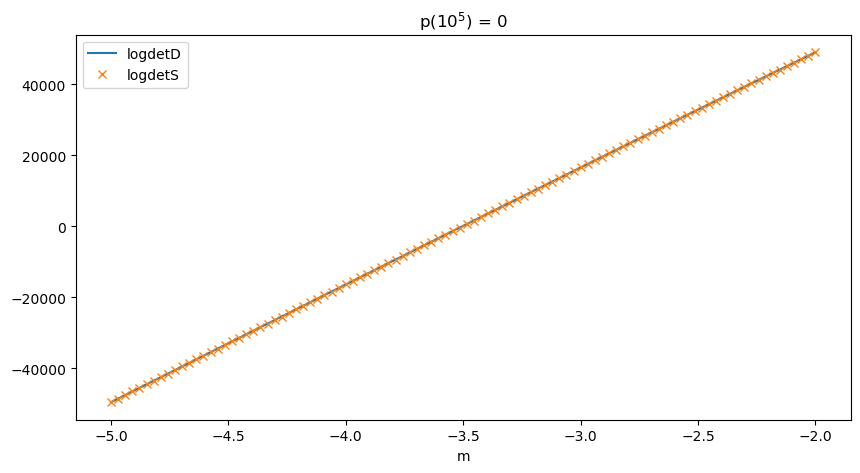

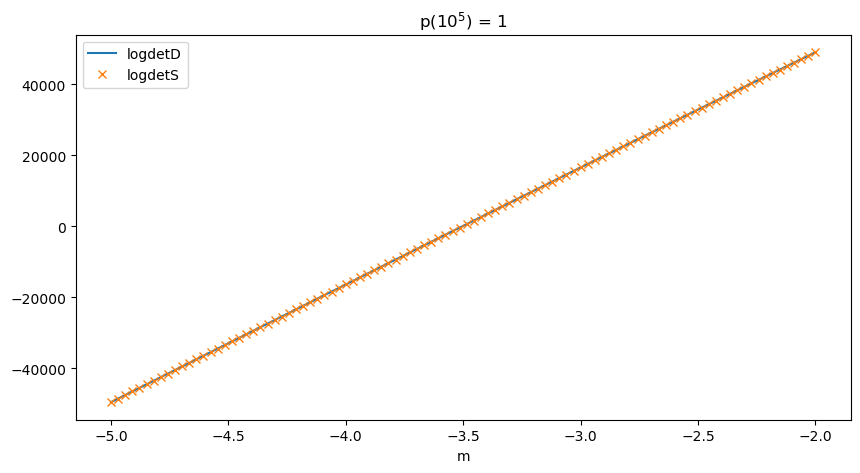

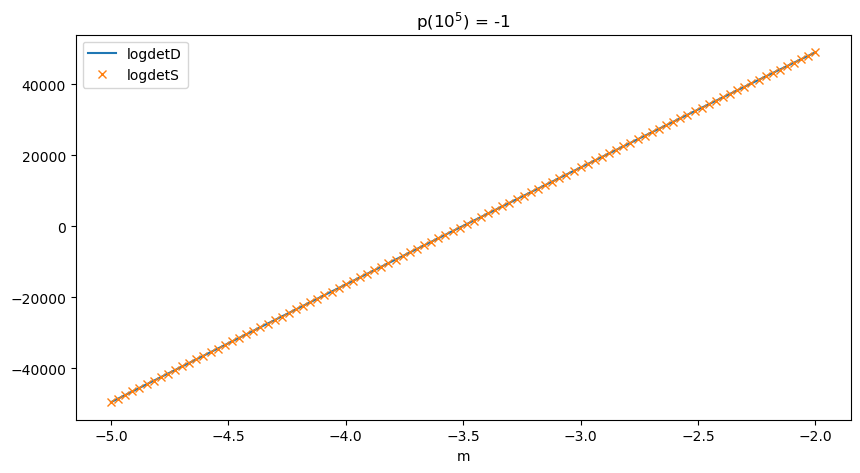

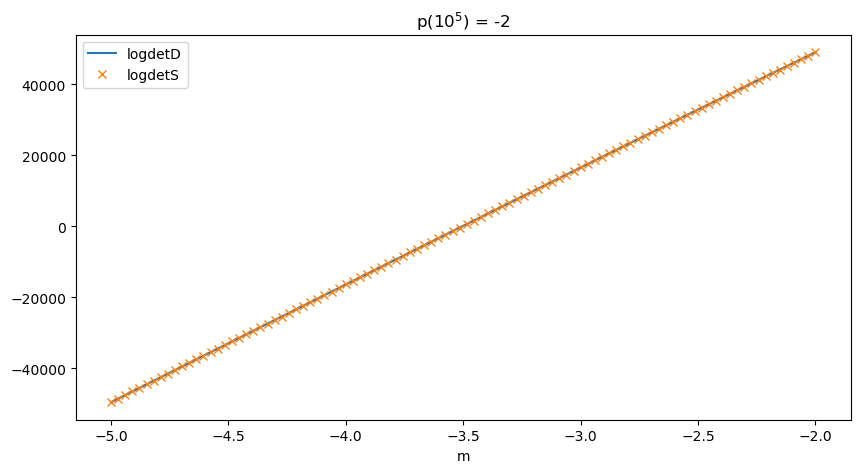

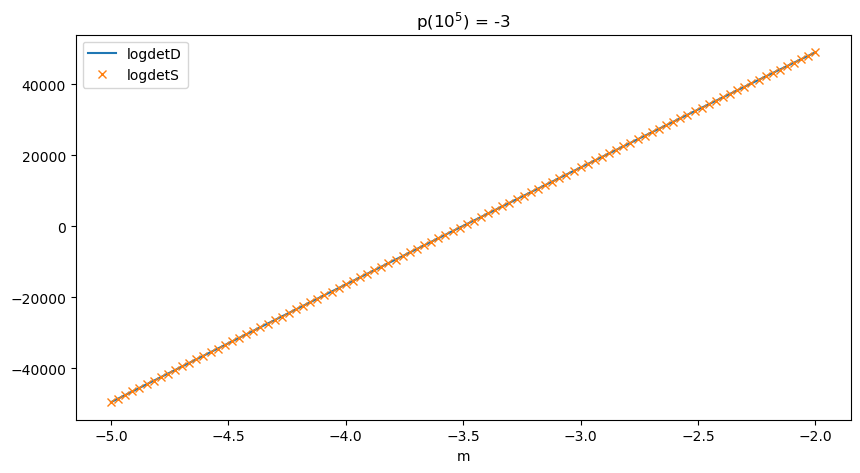

In [53]:
import pickle

def plot_change(arr, **kwargs):
    plt.plot(ms, np.array(arr)-np.mean(arr), **kwargs)

names_p = ['0', '1', 'm1', 'm2', 'm3']

ms = np.linspace(-2, -5, 100)

for i in range(len(names_p)):
    path =  dir + disc + f'_frank2d_varyingm_with_p{names_p[i]}.pkl'
    with open(path, 'rb') as f:
        dict_p = pickle.load(f)

        minus_log_likelihood_array = dict_p['minus_log_likelihood'][0]
        intensity_array = dict_p['intensity'][0]
        logdetS_array = dict_p['logdetS'][0]
        logdetD_array = dict_p['logdetD'][0]
        jTDj_array = dict_p['jTDj'][0]

        plt.figure(figsize=(10, 5))
        #plot_change(np.array(minus_log_likelihood_array), label='-log likelihood')
        #plt.plot(ms, p_m3_intensity, label = 'intensity')
        plot_change(np.array(logdetD_array), label='logdetD')
        plot_change(np.array(logdetS_array), marker = 'x', ls= 'None', label='logdetS')
        #plot_change(np.array(jTDj_array), label='jTDj')
        #plt.yscale('log')
        plt.legend()
        #plt.xlim(-2, -5)
        #plt.ylim(-4000, 4000)
        plt.xlabel('m')
        plt.title(r'p($10^5$) =' + f' {dict_p["p"]}')
        

    

### Plot

In [71]:
p_m3_minus_log_likelihood = minus_log_likelihood_array[0]
p_m2_minus_log_likelihood = minus_log_likelihood_array[1]
p_m1_minus_log_likelihood = minus_log_likelihood_array[2]
p_m0_minus_log_likelihood = minus_log_likelihood_array[3]
p_p1_minus_log_likelihood = minus_log_likelihood_array[4]

p_m3_intensity = intensity_array[0]
p_m2_intensity = intensity_array[1]
p_m1_intensity = intensity_array[2]
p_m0_intensity = intensity_array[3]
p_p1_intensity = intensity_array[4]

p_m3_logdetS = logdetS_array[0]
p_m2_logdetS = logdetS_array[1]
p_m1_logdetS = logdetS_array[2]
p_m0_logdetS = logdetS_array[3]
p_p1_logdetS = logdetS_array[4]

p_m3_logdetD = logdetD_array[0]
p_m2_logdetD = logdetD_array[1]
p_m1_logdetD = logdetD_array[2]
p_m0_logdetD = logdetD_array[3]
p_p1_logdetD = logdetD_array[4]

p_m3_jTDj = jTDj_array[0]
p_m2_jTDj = jTDj_array[1]
p_m1_jTDj = jTDj_array[2]
p_m0_jTDj = jTDj_array[3]
p_p1_jTDj = jTDj_array[4]



In [72]:
len(p_m3_minus_log_likelihood)

100

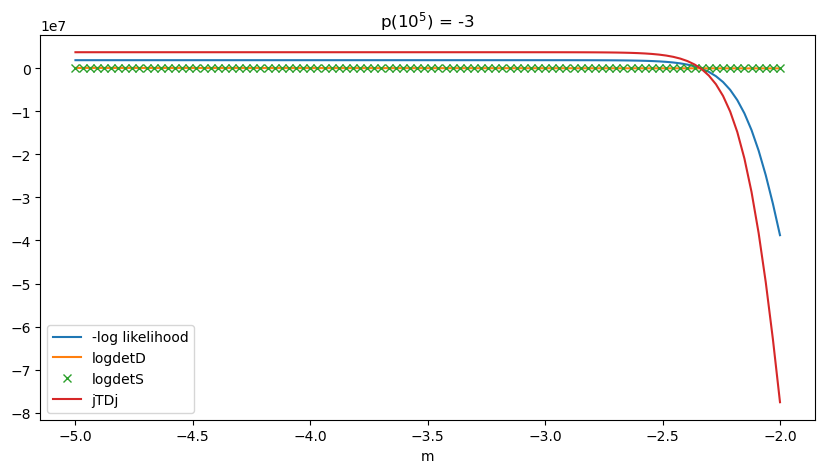

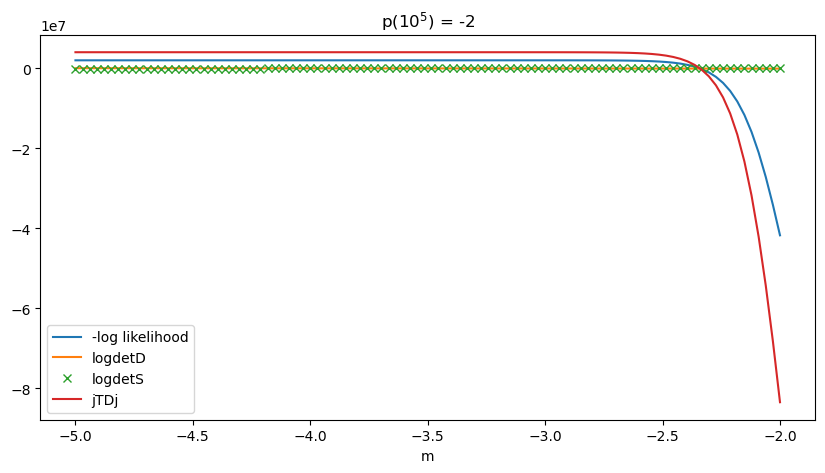

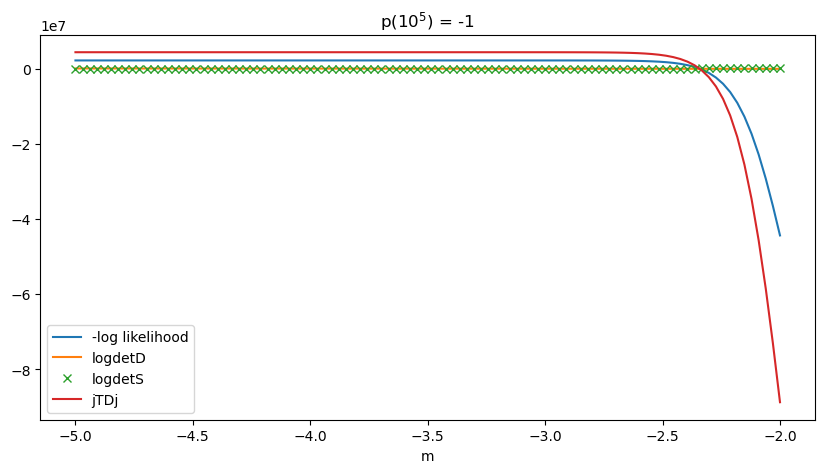

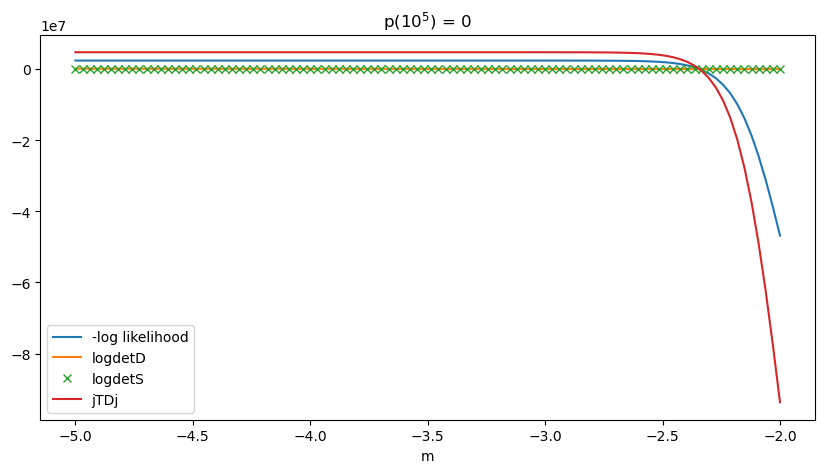

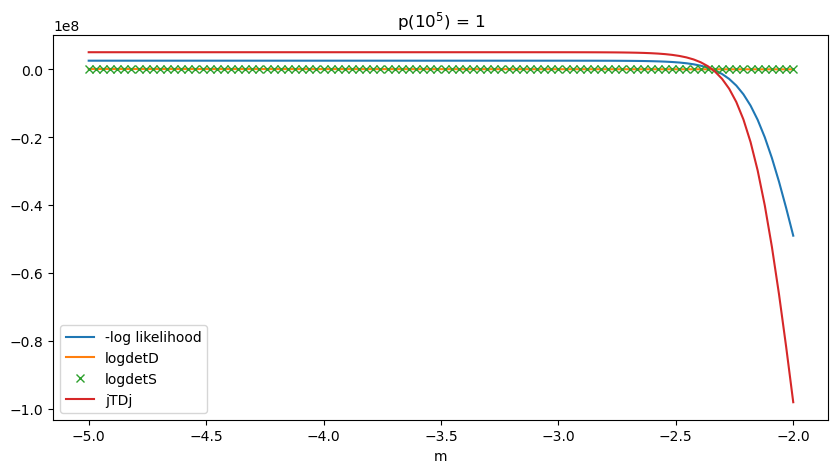

In [79]:
for i in range(len(minus_log_likelihood_array)):
    minus_log_likelihood = np.array(minus_log_likelihood_array[i])
    logdetS = np.array(logdetS_array[i])
    logdetD = np.array(logdetD_array[i])
    jTDj = np.array(jTDj_array[i])

    plt.figure(figsize=(10, 5))
    plot_change(minus_log_likelihood, label='-log likelihood')
    plot_change(-logdetD, label='logdetD')
    plot_change(logdetS, marker = 'x', ls= 'None', label='logdetS')
    plot_change(-jTDj, label='jTDj')
    #plt.yscale('log')
    plt.legend()
    plt.xlabel('m')
    plt.title(r'p($10^5$) =' + f' {ps[i]}')
    plt.show()
     